In [1]:
# import sys
# !{sys.executable} -m pip install streamlit

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# in this data set the concern is which item its subcategory shipping mode segment country or state mn sale ha kitni quantity mn or discount kya ha 

In [4]:
df = pd.read_csv('Sample_Superstore.csv', encoding = 'latin1')
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [5]:
print(df['State'])

0         Kentucky
1         Kentucky
2       California
3          Florida
4          Florida
           ...    
9989       Florida
9990    California
9991    California
9992    California
9993    California
Name: State, Length: 9994, dtype: object


In [6]:
df.shape

(9994, 21)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [8]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [9]:
columns = df[['Customer Name', 'Country', 'Category', 'Product Name' ]]
print(columns)

         Customer Name        Country         Category  \
0          Claire Gute  United States        Furniture   
1          Claire Gute  United States        Furniture   
2      Darrin Van Huff  United States  Office Supplies   
3       Sean O'Donnell  United States        Furniture   
4       Sean O'Donnell  United States  Office Supplies   
...                ...            ...              ...   
9989  Tom Boeckenhauer  United States        Furniture   
9990       Dave Brooks  United States        Furniture   
9991       Dave Brooks  United States       Technology   
9992       Dave Brooks  United States  Office Supplies   
9993      Chris Cortes  United States  Office Supplies   

                                           Product Name  
0                     Bush Somerset Collection Bookcase  
1     Hon Deluxe Fabric Upholstered Stacking Chairs,...  
2     Self-Adhesive Address Labels for Typewriters b...  
3         Bretford CR4500 Series Slim Rectangular Table  
4            

In [10]:
# indexed = df.set_index('name') # is used when two 
# print(df.loc[['Row name', 'column name']])
# print(df.loc[['Row name', 'column name'],['Row name 2', 'Column name 2']])
# print(df.iloc[0:3,0:3]) # iloc is used when index  is used used to extract or fatch data
# # in .loc set index is complusory othe er wise error and in .iloc there is no need of seeting index

In [11]:
# set_ind = df.set_index()

In [12]:
# df.sort_index()  # no any change

In [13]:
index = df.set_index('Customer Name')
print(index.loc['Darrin Van Huff', 'Profit'])

Customer Name
Darrin Van Huff      6.8714
Darrin Van Huff     -2.6936
Darrin Van Huff      1.9176
Darrin Van Huff      8.6940
Darrin Van Huff      5.3680
Darrin Van Huff   -420.0000
Darrin Van Huff    -16.5528
Darrin Van Huff      1.3584
Darrin Van Huff    -12.1470
Name: Profit, dtype: float64


In [14]:
# print(df.describe(include=all)) ## in that decsribe is not print
df.describe() ## in that table there is fluctutaions in mean(229.85) ond median(54.49) of sales 
# mean (3.789574) and median(3) in quantity
# In discount mean is 0.20, median is 0.15
# most outliers or problem is in profit column   mean = 28.66 or median = 8

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [15]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [16]:
print(df.isna())

      Row ID  Order ID  Order Date  Ship Date  Ship Mode  Customer ID  \
0      False     False       False      False      False        False   
1      False     False       False      False      False        False   
2      False     False       False      False      False        False   
3      False     False       False      False      False        False   
4      False     False       False      False      False        False   
...      ...       ...         ...        ...        ...          ...   
9989   False     False       False      False      False        False   
9990   False     False       False      False      False        False   
9991   False     False       False      False      False        False   
9992   False     False       False      False      False        False   
9993   False     False       False      False      False        False   

      Customer Name  Segment  Country   City  ...  Postal Code  Region  \
0             False    False    False  False  ...

In [17]:
print(df.isna().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [18]:
df = df.drop_duplicates().copy()
# no value remove it means no duplicate row
print(df)

      Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0          1  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
1          2  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
2          3  CA-2016-138688   6/12/2016   6/16/2016    Second Class   
3          4  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
4          5  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
...      ...             ...         ...         ...             ...   
9989    9990  CA-2014-110422   1/21/2014   1/23/2014    Second Class   
9990    9991  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9991    9992  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9992    9993  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9993    9994  CA-2017-119914    5/4/2017    5/9/2017    Second Class   

     Customer ID     Customer Name    Segment        Country             City  \
0       CG-12520       Claire Gute   Consumer  United 

In [19]:
df['City'] = df['City'].str.strip()
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [20]:
Product_Name = df['Product Name']
print(Product_Name)

0                       Bush Somerset Collection Bookcase
1       Hon Deluxe Fabric Upholstered Stacking Chairs,...
2       Self-Adhesive Address Labels for Typewriters b...
3           Bretford CR4500 Series Slim Rectangular Table
4                          Eldon Fold 'N Roll Cart System
                              ...                        
9989                               Ultra Door Pull Handle
9990    Tenex B1-RE Series Chair Mats for Low Pile Car...
9991                                Aastra 57i VoIP phone
9992    It's Hot Message Books with Stickers, 2 3/4" x 5"
9993    Acco 7-Outlet Masterpiece Power Center, Wihtou...
Name: Product Name, Length: 9994, dtype: object


In [21]:
df['Ship Date'].head()

0    11/11/2016
1    11/11/2016
2     6/16/2016
3    10/18/2015
4    10/18/2015
Name: Ship Date, dtype: object

In [22]:
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [23]:
print(len(df))


9994


In [24]:
df['Shipping_Days'] = (
    pd.to_datetime(df['Ship Date']) - pd.to_datetime(df['Order Date'])
).dt.days

df = df.drop(['Order Date', 'Ship Date'], axis=1)

In [25]:
subset=df[['Category', 'Sales', 'Profit', 'Region']]
print(subset.head(7))

          Category     Sales    Profit Region
0        Furniture  261.9600   41.9136  South
1        Furniture  731.9400  219.5820  South
2  Office Supplies   14.6200    6.8714   West
3        Furniture  957.5775 -383.0310  South
4  Office Supplies   22.3680    2.5164  South
5        Furniture   48.8600   14.1694   West
6  Office Supplies    7.2800    1.9656   West


In [26]:
loss  = df[df['Profit'] > 0]
print(loss)

      Row ID        Order ID       Ship Mode Customer ID     Customer Name  \
0          1  CA-2016-152156    Second Class    CG-12520       Claire Gute   
1          2  CA-2016-152156    Second Class    CG-12520       Claire Gute   
2          3  CA-2016-138688    Second Class    DV-13045   Darrin Van Huff   
4          5  US-2015-108966  Standard Class    SO-20335    Sean O'Donnell   
5          6  CA-2014-115812  Standard Class    BH-11710   Brosina Hoffman   
...      ...             ...             ...         ...               ...   
9989    9990  CA-2014-110422    Second Class    TB-21400  Tom Boeckenhauer   
9990    9991  CA-2017-121258  Standard Class    DB-13060       Dave Brooks   
9991    9992  CA-2017-121258  Standard Class    DB-13060       Dave Brooks   
9992    9993  CA-2017-121258  Standard Class    DB-13060       Dave Brooks   
9993    9994  CA-2017-119914    Second Class    CC-12220      Chris Cortes   

        Segment        Country             City       State  Po

In [27]:
sales_by_category = df.groupby('Category')[['Sales', 'Profit']].sum()
print(sales_by_category)

                       Sales       Profit
Category                                 
Furniture        741999.7953   18451.2728
Office Supplies  719047.0320  122490.8008
Technology       836154.0330  145454.9481


In [28]:
sales_by_region = df.groupby('Region')['Sales'].sum()
sales_by_region = sales_by_region.sort_values(ascending=False)
print(sales_by_region)


Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


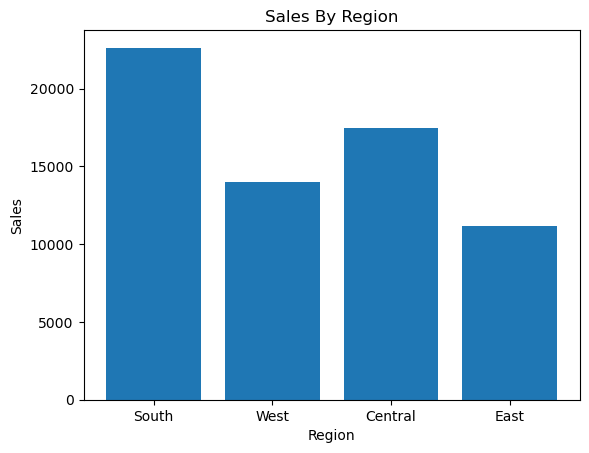

In [29]:
import matplotlib.pyplot as plt
import numpy as np
plt.title("Sales By Region")
x = np.array(df['Region'])
y = np.array(df['Sales'])
plt.xlabel('Region')
plt.ylabel("Sales")

plt.bar(x,y)
plt.show()

In [30]:
profit_by_region = df.groupby('Region')['Profit'].sum()
profit_by_region = profit_by_region.sort_values(ascending=False)
print(profit_by_region)


Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


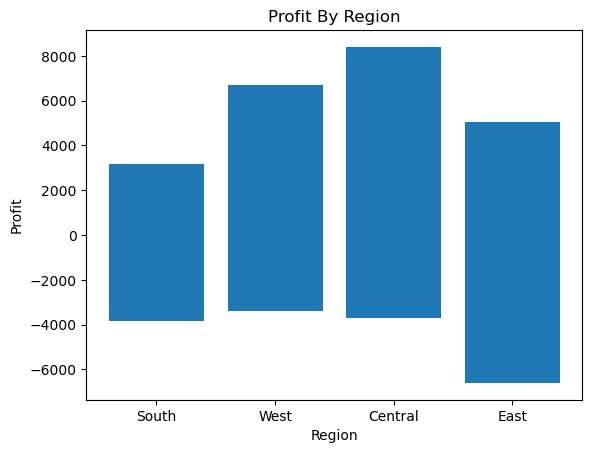

In [31]:
import numpy as np
plt.title("Profit By Region")
x = np.array(df['Region'])
y = np.array(df['Profit'])
plt.xlabel('Region')
plt.ylabel("Profit")

plt.bar(x,y)
plt.show()

In [32]:
sales_by_category = df.groupby('Category')['Sales'].sum()
sales_by_category = sales_by_category.sort_values(ascending=False)
print(sales_by_category)


Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


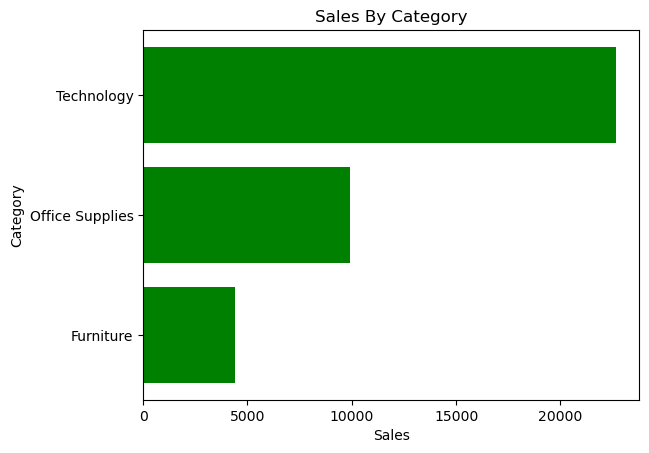

In [33]:
import numpy as np
plt.title("Sales By Category")
x = np.array(df['Category'])
y = np.array(df['Sales'])
plt.xlabel('Sales')
plt.ylabel("Category")

plt.barh(x,y , color ="green")
plt.show()

In [34]:
profit_by_category = df.groupby('Category')['Profit'].sum()
profit_by_category = profit_by_category.sort_values(ascending=False)
print(profit_by_category)


Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


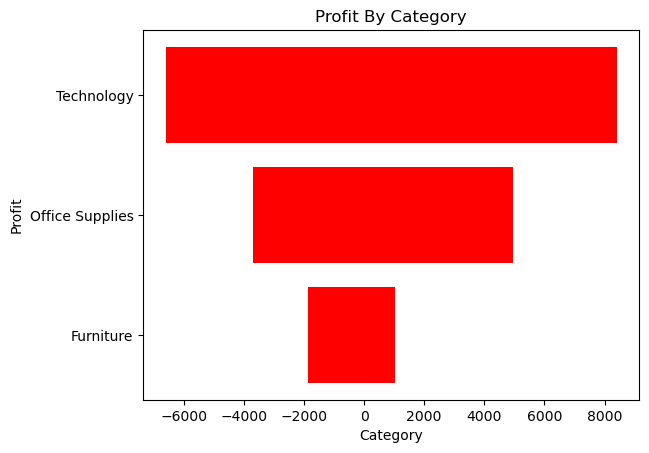

In [35]:
import numpy as np
plt.title("Profit By Category")
x = np.array(df['Category'])
y = np.array(df['Profit'])
plt.xlabel('Category')
plt.ylabel('Profit')

plt.barh(x,y , color ="red")
plt.show()

In [36]:
# Furniture → Region → Sales + Profit
furniture_df = df[df['Category'] == 'Furniture']

furniture_analysis = furniture_df.groupby('Region')[['Sales', 'Profit']].sum()

furniture_analysis

,Sales,Profit
Region,,
Central,163797.1638,-2871.0494
East,208291.2040,3046.1658
South,117298.6840,6771.2061
West,252612.7435,11504.9503


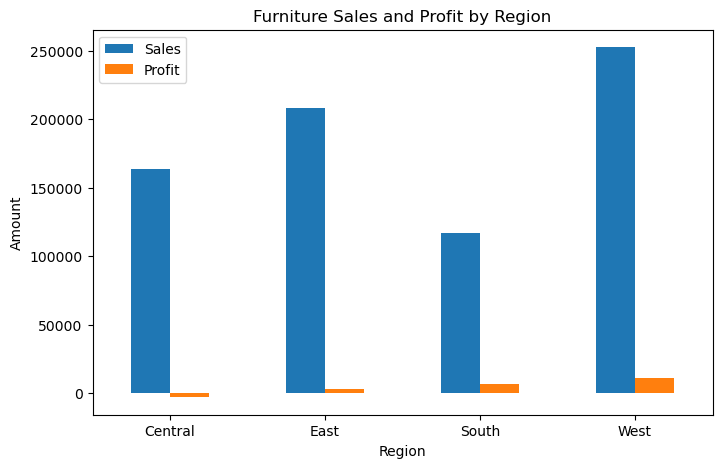

In [41]:
import matplotlib.pyplot as plt

furniture_analysis.plot(kind='bar', figsize=(8,5))

plt.title('Furniture Sales and Profit by Region')
plt.xlabel('Region')
plt.ylabel('Amount')
plt.xticks(rotation=0)
plt.legend(['Sales', 'Profit'])
plt.show()

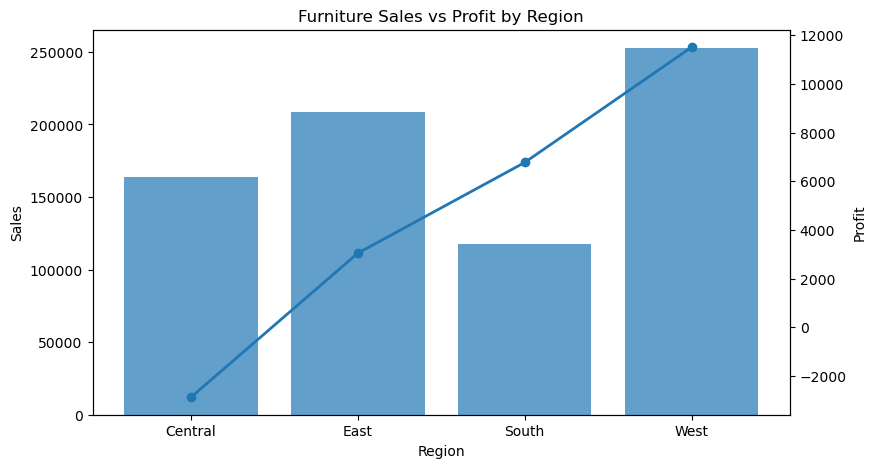

In [42]:


import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(9, 5))

# Sales
ax1.bar(
    furniture_analysis.index,
    furniture_analysis['Sales'],
    alpha=0.7,
    label='Sales'
)

ax1.set_xlabel('Region')
ax1.set_ylabel('Sales')

# Profit
ax2 = ax1.twinx()

ax2.plot(
    furniture_analysis.index,
    furniture_analysis['Profit'],
    marker='o',
    linewidth=2,
    label='Profit'
)

ax2.set_ylabel('Profit')

plt.title('Furniture Sales vs Profit by Region')
plt.show()

